In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォントなどの設定（必要に応じて適用）
# plt.rcParams['font.family'] = 'AppleGothic'  # Macの場合

def load_experiment_data(base_dir, experiment_names):
    """
    複数実験の推論結果と評価指標をdict構造に一括で読み込む。
    各foldのNumpy配列は (N, T, F) に自動で結合される。
    """
    data_dict = {}
    for exp_name in experiment_names:
        exp_dir = os.path.join(base_dir, exp_name)
        summary_path = os.path.join(exp_dir, 'feature_summary.csv')
        
        if not os.path.exists(summary_path):
            print(f"Warning: {summary_path} が見つかりません。スキップします。")
            continue
            
        # 1. 評価指標の読み込み
        df_summary = pd.read_csv(summary_path)
        
        # 2. 推論配列と実測値配列の集約
        preds_list, targets_list = [], []
        for fold in range(1, 7):  # Fold 1~6 を前提
            pred_path = os.path.join(exp_dir, f'preds_fold{fold}.npy')
            targ_path = os.path.join(exp_dir, f'targets_fold{fold}.npy')
            
            if os.path.exists(pred_path) and os.path.exists(targ_path):
                preds_list.append(np.load(pred_path))
                targets_list.append(np.load(targ_path))
                
        if not preds_list:
            print(f"Warning: {exp_name} にNumpy配列が保存されていません。")
            continue
            
        # 全Foldの波形を縦方向(サンプル単位)に結合 => shape: (N_total, T, F)
        preds = np.concatenate(preds_list, axis=0)
        targets = np.concatenate(targets_list, axis=0)
        
        data_dict[exp_name] = {
            'summary': df_summary,
            'preds': preds,
            'targets': targets,
            'features': df_summary['feature'].tolist()
        }
    return data_dict


In [28]:
def create_comparison_tables(data_dict, metrics=None):
    """
    各指標ごとに mean±std 形式の比較表を作成して表示する．
    
    Parameters
    ----------
    data_dict : dict
        load_experiment_data() の戻り値
    metrics : list[str] or None
        表示したい指標名のリスト（例: ['rmse', 'nrmse', 'mae', 'r2']）
        None の場合は feature_summary.csv の列から自動検出
    """
    exp_names = list(data_dict.keys())
    if not exp_names:
        return

    # --- 指標名の自動検出 ---
    if metrics is None:
        cols = data_dict[exp_names[0]]['summary'].columns.tolist()
        # "_mean" で終わる列から指標名を抽出
        metrics = [c.replace('_mean', '') for c in cols if c.endswith('_mean')]

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        records = {}
        for exp_name in exp_names:
            df = data_dict[exp_name]['summary']

            if mean_col not in df.columns:
                continue

            row_dict = {}
            for _, row in df.iterrows():
                feature = row['feature']
                mean_val = row[mean_col]
                std_val  = row[std_col] if std_col in df.columns else float('nan')
                # "0.0215±0.0026" 形式の文字列
                row_dict[feature] = f"{mean_val:.4f}±{std_val:.4f}"

            # 全体平均（数値のみ）を最後列に追加
            row_dict['Overall_Mean'] = df[mean_col].mean()
            records[exp_name] = row_dict

        if not records:
            print(f"[{metric}] データが見つかりませんでした．スキップします．")
            continue

        df_table = pd.DataFrame.from_dict(records, orient='index')

        # Overall_Mean（数値）でソートしてから列を削除
        sort_ascending = metric != 'r2'  # r2 は高い順，誤差系は低い順
        df_table = df_table.sort_values('Overall_Mean', ascending=sort_ascending)
        df_table = df_table.drop(columns=['Overall_Mean'])

        print(f"\n{'='*60}")
        print(f"  {mean_col}  ±  {std_col}")
        print(f"{'='*60}")
        display(df_table) 

def plot_metrics_bar(data_dict, metrics=None):
    """
    全指標を自動検出し，指標ごとに figure を作成．
    各 figure は特徴量ごとのサブプロットで，各モデルの Bar plot (+エラーバー) を表示．

    Parameters
    ----------
    data_dict : dict
        load_experiment_data() の戻り値
    metrics : list[str] or None
        表示したい指標名のリスト（例: ['rmse', 'nrmse', 'mae', 'r2']）
        None の場合は feature_summary.csv の列から自動検出
    """
    exp_names = list(data_dict.keys())
    if not exp_names:
        return

    features = data_dict[exp_names[0]]['features']
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = int(np.ceil(n_features / n_cols))

    # --- 指標名の自動検出 ---
    if metrics is None:
        cols = data_dict[exp_names[0]]['summary'].columns.tolist()
        metrics = [c.replace('_mean', '') for c in cols if c.endswith('_mean')]

    x = np.arange(len(exp_names))

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        # 指標が存在しない場合はスキップ
        if mean_col not in data_dict[exp_names[0]]['summary'].columns:
            print(f"[{mean_col}] が見つかりません．スキップします．")
            continue

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
        fig.suptitle(f'Metric: {metric.upper()}', fontsize=14, y=1.01)

        if n_features == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for i, feature in enumerate(features):
            ax = axes[i]
            means, stds = [], []

            for exp in exp_names:
                df  = data_dict[exp]['summary']
                row = df[df['feature'] == feature]
                if not row.empty:
                    means.append(row[mean_col].values[0])
                    stds.append(row[std_col].values[0] if std_col in df.columns else 0)
                else:
                    means.append(0)
                    stds.append(0)

            ax.bar(
                x, means,
                yerr=stds, capsize=5,
                color='cornflowerblue', edgecolor='k', alpha=0.8
            )
            ax.set_xticks(x)
            ax.set_xticklabels(exp_names, rotation=45, ha='right')
            ax.set_title(f'[{feature}]')
            ax.set_ylabel(metric.upper())
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        # 余分な軸を削除
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

In [29]:
def plot_waveform_comparison(data_dict):
    """全モデルの平均予測波形と、真値の(平均±1SD帯)を重ねて可視化"""
    exp_names = list(data_dict.keys())
    if not exp_names: return
    features = data_dict[exp_names[0]]['features']
    
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_features == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    # ターゲット波形テンソルを基準に時間軸(%)を定義
    base_targets = data_dict[exp_names[0]]['targets']
    time_pts = np.linspace(0, 100, base_targets.shape[1])
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # 真値の計算（Nサンプル方向への平均）
        true_mean = np.mean(base_targets[:, :, i], axis=0)
        true_std = np.std(base_targets[:, :, i], axis=0)
        
        # 真値をプロットとグレー帯域塗布
        ax.plot(time_pts, true_mean, label='True Mean', color='black', lw=2)
        ax.fill_between(time_pts, true_mean - true_std, true_mean + true_std, color='gray', alpha=0.2, label='True ±1SD')
        
        # モデルごとの予測推移を実線で重畳
        for exp in exp_names:
            preds = data_dict[exp]['preds']
            pred_mean = np.mean(preds[:, :, i], axis=0)
            ax.plot(time_pts, pred_mean, label=f'{exp}', linestyle='--')
            
        ax.set_title(f'Waveforms: {feature}')
        ax.set_xlabel('Gait Cycle (%)')
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize='small', loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def plot_error_time_series(data_dict):
    """Error = Pred - Trueの平均・標準偏差帯を時間方向でプロット"""
    exp_names = list(data_dict.keys())
    if not exp_names: return
    features = data_dict[exp_names[0]]['features']
    
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_features == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    time_pts = np.linspace(0, 100, data_dict[exp_names[0]]['targets'].shape[1])
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        for idx, exp in enumerate(exp_names):
            error = data_dict[exp]['preds'][:, :, i] - data_dict[exp]['targets'][:, :, i]
            mean_error = np.mean(error, axis=0)
            std_error = np.std(error, axis=0)
            
            c = colors[idx % len(colors)]
            ax.plot(time_pts, mean_error, label=exp, color=c)
            # エラー誤差幅の帯
            ax.fill_between(time_pts, mean_error - std_error, mean_error + std_error, color=c, alpha=0.1)
            
        ax.axhline(0, color='black', lw=1.5)  # 誤差0のベースライン
        ax.set_title(f'Error Evolution: {feature}')
        ax.set_xlabel('Gait Cycle (%)')
        ax.set_ylabel('Error (Pred - True)')
        ax.legend(fontsize='x-small', loc='best')
        ax.grid(True, linestyle=':', alpha=0.6)
        
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()



  rmse_mean  ±  rmse_std


,Fx,Fy,Fz
transformer_grf_single_transformer_20260421_053321,0.0193±0.0016,0.0284±0.0023,0.0608±0.0064
transformer_grf_pressure_single_weighted_transformer_20260421_074422,0.0194±0.0022,0.0307±0.0065,0.0655±0.0134
transformer_grf_single_weighted_transformer_20260421_055208,0.0195±0.0013,0.0269±0.0025,0.0705±0.0094
bilstm_grf_single_bilstm_20260421_040951,0.0215±0.0026,0.0358±0.0057,0.0738±0.0119
cnn_grf_single_cnn_20260421_040528,0.0204±0.0031,0.0414±0.0044,0.1050±0.0132



  nrmse_mean  ±  nrmse_std


,Fx,Fy,Fz
transformer_grf_single_transformer_20260421_053321,0.0920±0.0070,0.0487±0.0058,0.0408±0.0020
transformer_grf_single_weighted_transformer_20260421_055208,0.0930±0.0103,0.0461±0.0062,0.0473±0.0039
transformer_grf_pressure_single_weighted_transformer_20260421_074422,0.0919±0.0059,0.0523±0.0097,0.0438±0.0074
bilstm_grf_single_bilstm_20260421_040951,0.1023±0.0133,0.0607±0.0063,0.0499±0.0098
cnn_grf_single_cnn_20260421_040528,0.0966±0.0070,0.0711±0.0117,0.0703±0.0033



  mae_mean  ±  mae_std


,Fx,Fy,Fz
transformer_grf_single_transformer_20260421_053321,0.0153±0.0016,0.0219±0.0023,0.0386±0.0038
transformer_grf_single_weighted_transformer_20260421_055208,0.0155±0.0012,0.0209±0.0022,0.0454±0.0064
transformer_grf_pressure_single_weighted_transformer_20260421_074422,0.0157±0.0017,0.0239±0.0049,0.0450±0.0090
bilstm_grf_single_bilstm_20260421_040951,0.0173±0.0023,0.0265±0.0033,0.0515±0.0061
cnn_grf_single_cnn_20260421_040528,0.0163±0.0022,0.0307±0.0033,0.0720±0.0097



  r2_mean  ±  r2_std


,Fx,Fy,Fz
transformer_grf_single_weighted_transformer_20260421_055208,0.7199±0.0292,0.9022±0.0249,0.9776±0.0053
transformer_grf_single_transformer_20260421_053321,0.7238±0.0387,0.8915±0.0224,0.9835±0.0032
transformer_grf_pressure_single_weighted_transformer_20260421_074422,0.7230±0.0452,0.8723±0.0503,0.9803±0.0076
bilstm_grf_single_bilstm_20260421_040951,0.6594±0.0568,0.8308±0.0364,0.9753±0.0079
cnn_grf_single_cnn_20260421_040528,0.6909±0.0679,0.7712±0.0491,0.9506±0.0114


/tmp/ipykernel_93337/848051730.py:136: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


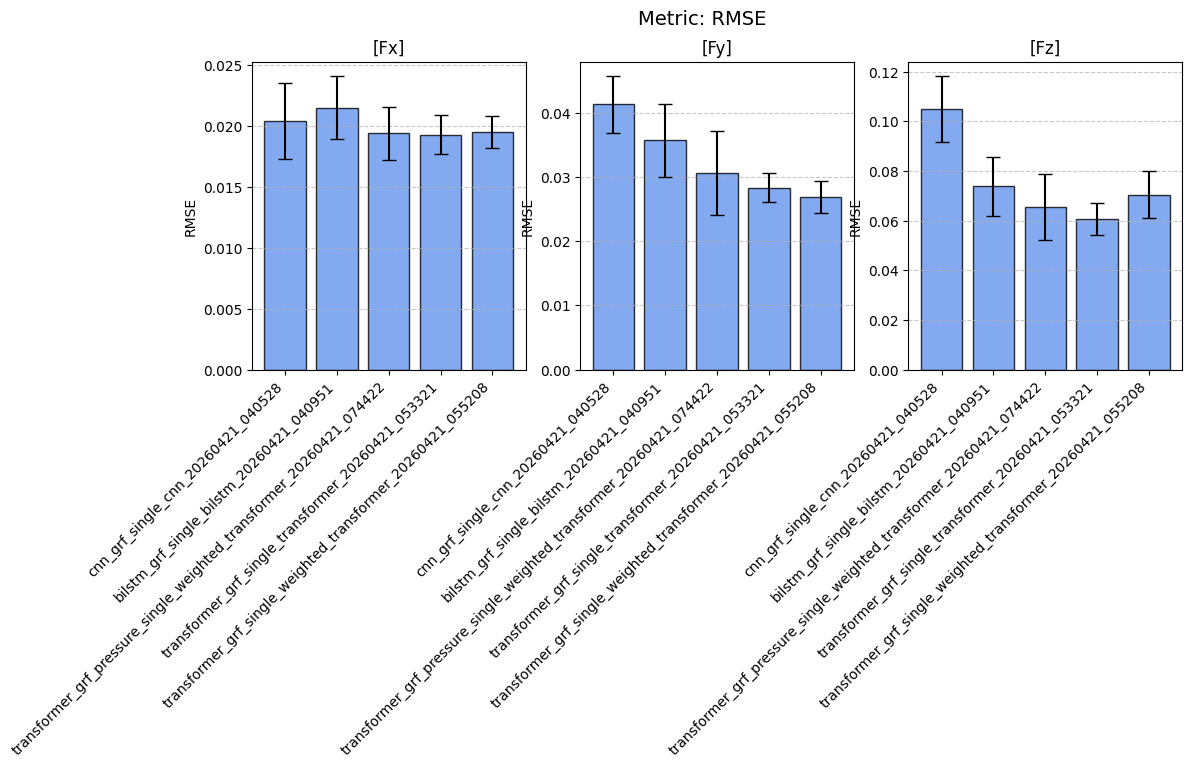

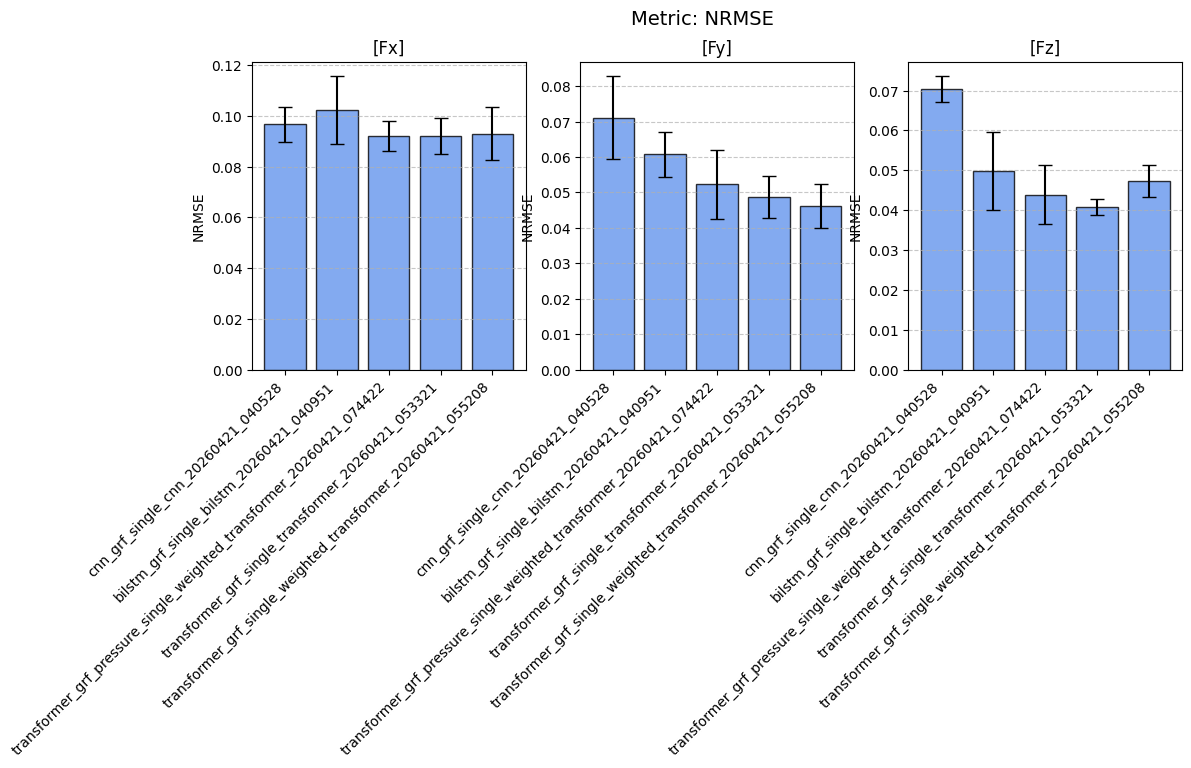

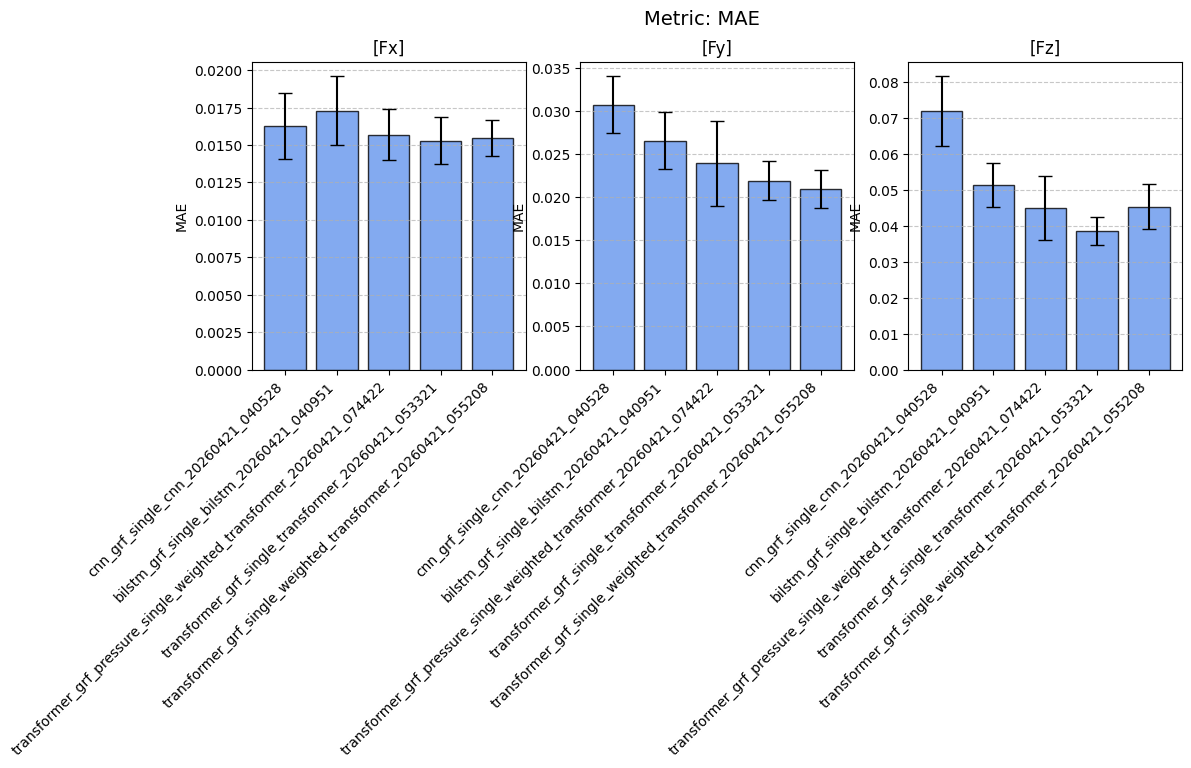

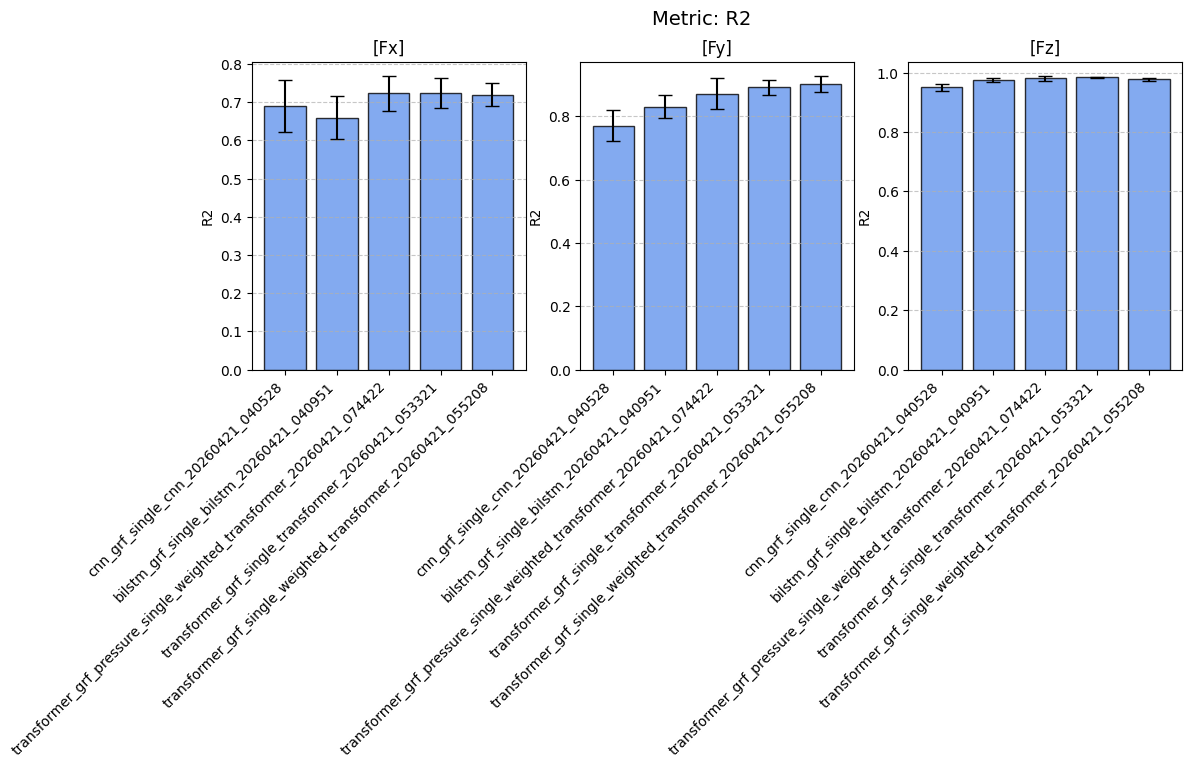

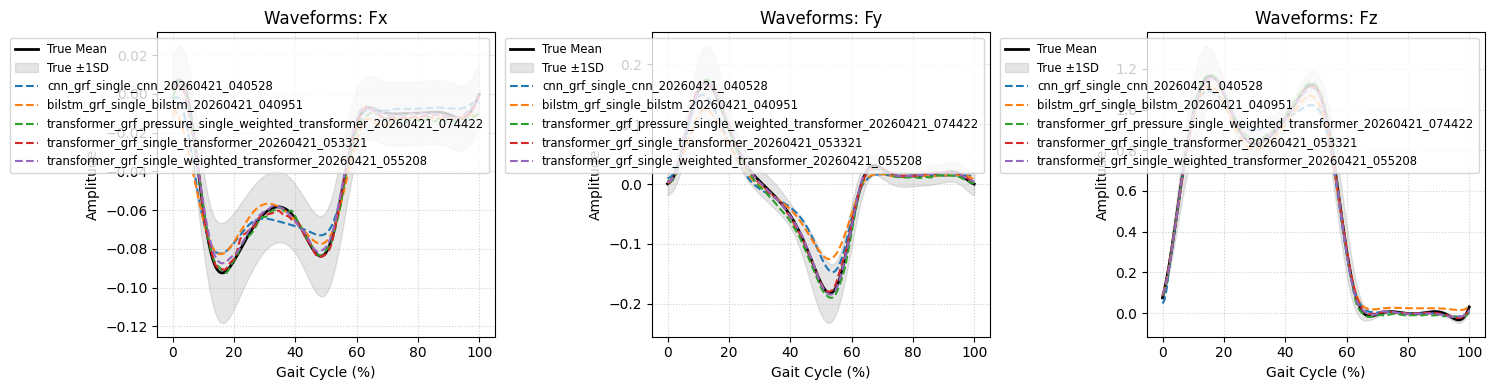

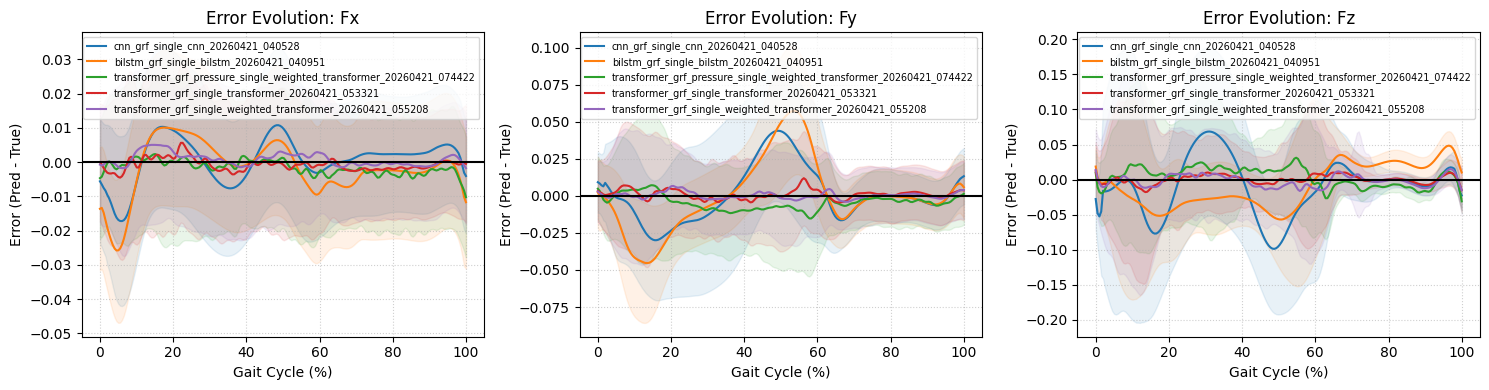

In [31]:
# 対象の実験ディレクトリが格納されている親パス
BASE_DIR = "../outputs/experiments"

# 比較したい実験リストを直接書くか、glob等で取得します
experiments = [
    "cnn_grf_single_cnn_20260421_040528",
    "bilstm_grf_single_bilstm_20260421_040951",
    "transformer_grf_pressure_single_weighted_transformer_20260421_074422",
    "transformer_grf_single_transformer_20260421_053321",
    "transformer_grf_single_weighted_transformer_20260421_055208",
]

# 1. データのロード
data = load_experiment_data(BASE_DIR, experiments)

# 2. 定量評価の表示
df_r2 = create_comparison_tables(data)

# 3. Bar Plot の表示
plot_metrics_bar(data) 

# 4. 波形比較の表示
plot_waveform_comparison(data)

# 5. 時間軸エラー分析の表示
plot_error_time_series(data)

